----

In [1]:
# standard libraries
import pandas as pd
import numpy as np
import math as mt
from math import factorial

# visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# statistical libraries
from scipy import stats
from scipy import stats as st

##### Project Overview: 
- Market Analysis for Ice Online Store
"You work for Ice, an international online video game retailer. The dataset includes open-source information regarding user and expert reviews, genres, platforms (e.g., Xbox or PlayStation), and historical sales data.

- The objective: To identify key patterns that determine a game's success. This analysis will enable the identification of promising projects and the strategic planning of advertising campaigns.

- Key Task: Using data up to 2016, you will act as a Data Analyst in December 2016 planning for the 2017 fiscal year, gaining experience in trend forecasting and data-driven decision-making."

In [2]:
### Step 1: Data Loading & Initial Inspection

df_games = pd.read_csv('datasets/games.csv', sep=',')
print(df_games.info())
print('_'*30)
display(df_games.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None
______________________________


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


##### Step 2: Data Preparation
##### In this phase, we will clean and transform the raw data to ensure it is suitable for analysis. This involves standardizing formats, handling missing values, and engineering new features.

- 1. Column Standardization
Replace column names with lowercase characters (using snake_case for better readability and accessibility).

- 2. Type Conversion
Convert data types to the appropriate formats (e.g., dates, floats, and integers).

- Documentation: I will describe the columns where data types were changed and provide a clear explanation of why these adjustments were necessary.

- 3. Missing Values Treatment
 Identify and address missing values across the dataset.

 Justification: I will explain the reasoning behind filling missing values or why certain rows were left blank.

 Root Cause Analysis: Provide potential explanations for why the data might be missing in the first place.

 Handling "TBD" (To Be Determined): I will specify the strategy for managing cases marked as "TBD," particularly in the review scores, and explain its impact on the analysis.

- 4. Feature Engineering
Total Sales Calculation: Calculate total sales (the sum of revenue from all regions) for each game and store these values in a new, dedicated column.

In [3]:
# Replace column names with lowercase
df_games.columns = df_games.columns.str.lower()

print("Columns converted to lowercase:")
print(df_games.columns.tolist())
display(df_games.head())

Columns converted to lowercase:
['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating']


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [4]:
# Missing values per column
print("Missing values per column:")
missing_data = df_games.isnull().sum()

# Filtering only columns with missing values for clarity
print(missing_data[missing_data > 0])

display(df_games.head())

Missing values per column:
name                  2
year_of_release     269
genre                 2
critic_score       8578
user_score         6701
rating             6766
dtype: int64


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


- Convert the data to the necessary types. Describe the columns where the data types have been changed and explain why.

In [5]:
# Check current data types
print("Current data types:")
print(df_games.dtypes)

Current data types:
name                object
platform            object
year_of_release    float64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score          object
rating              object
dtype: object


In [6]:

# Counting missing values in the 'year_of_release' column
print(f"Total missing values in 'year_of_release': {df_games['year_of_release'].isnull().sum()}")

Total missing values in 'year_of_release': 269


In [7]:
# Convert all genres in the 'genre' column to lowercase
df_games['genre'] = df_games['genre'].str.lower()

# Verification
print("Sample of standardized genres:")
print(df_games['genre'].unique()[:5])

Sample of standardized genres:
['sports' 'platform' 'racing' 'role-playing' 'puzzle']


In [8]:
# Necessary conversions:

# Converting 'year_of_release' to numeric (float initially due to NaNs)
df_games['year_of_release'] = pd.to_numeric(df_games['year_of_release'], errors='coerce')

# Converting 'user_score' to numeric (this handles 'tbd' by converting it to NaN)
df_games['user_score'] = pd.to_numeric(df_games['user_score'], errors='coerce')

# Optional: 'critic_score' is usually already numeric, but we ensure consistency
# df_games['critic_score'] = pd.to_numeric(df_games['critic_score'], errors='coerce')

print("Data types after conversion:")
print(df_games[['year_of_release', 'user_score']].dtypes)

Data types after conversion:
year_of_release    float64
user_score         float64
dtype: object


- "I have successfully pre-processed the user_score, year_of_release, and genre columns. These conversions are essential for the upcoming stages of the analysis:

- user_score & year_of_release: Converted to numeric types to enable statistical calculations and time-series trend analysis.

- genre: Standardized to lowercase to ensure data consistency and prevent duplication during grouping and visualization."

In [9]:
# Verifying the new data type for 'year_of_release'
print(f"Data type for year_of_release: {df_games['year_of_release'].dtype}")

# Confirming that null values were preserved
print(f"Null values in year_of_release: {df_games['year_of_release'].isnull().sum()}")

# Verifying the new data type for 'user_score'
print(f"Data type for user_score: {df_games['user_score'].dtype}")

# Confirming that null values were preserved (including former 'tbd' entries)
print(f"Null values in user_score: {df_games['user_score'].isnull().sum()}")

Data type for year_of_release: float64
Null values in year_of_release: 269
Data type for user_score: float64
Null values in user_score: 9125


In [10]:
# Strategic handling of missing values

# Verifying missing values
print("Missing values per column:")
print(df_games.isnull().sum())

Missing values per column:
name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64


In [11]:
df_games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,NES,1985.0,platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,role-playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [14]:
# Visualizing rating classifications
print("Unique values in 'rating':")

# Using dropna=False in value_counts to keep track of missing values
print(df_games['rating'].value_counts(dropna=False))


Unique values in 'rating':
rating
NaN     6766
E       3990
T       2961
M       1563
E10+    1420
EC         8
K-A        3
RP         3
AO         1
Name: count, dtype: int64


##### E= EVERYONE
##### T= TEEN
##### M= MATURE
##### E10+= EVERYONE +10
##### EC= 8 EARLY CHILDREN
##### K-A= KIDS TO ADULTS (Clasificacion antigua)
##### RP= (Rating pending)
##### AO= (Adults Only)

##### CLASIFICACIONES PRINCIPALES (ESRB):
E (3990): Everyone - Para todos
- T (2961): Teen - Adolescentes (13+)
- M (1563): Mature - Adultos (17+)
- E10+ (1420): Everyone 10+ - Mayores de 10 años
##### Clasificaciones especiales/raras:
- EC (8): Early Childhood - Primera infancia (3+)
- K-A (3): Kids to Adults - Clasificación antigua (reemplazada por E)
- RP (3): Rating Pending - Pendiente de clasificación
- AO (1): Adults Only - Solo adultos (18+)
##### Valores ausentes:
- NaN (6766): Sin información de clasificación

In [15]:
# Unifying legacy rating classifications

# Converting 'K-A' (legacy rating) to 'E' (current Everyone rating)
df_games['rating'] = df_games['rating'].replace('K-A', 'E')

print("After unifying K-A -> E:")
print(df_games['rating'].value_counts(dropna=False))

After unifying K-A -> E:
rating
NaN     6766
E       3993
T       2961
M       1563
E10+    1420
EC         8
RP         3
AO         1
Name: count, dtype: int64


In [16]:
# Handling special cases

# Converting 'RP' (Rating Pending) to NaN as it provides no classification info
df_games['rating'] = df_games['rating'].replace('RP', np.nan)

# Keeping 'EC' (Early Childhood) and 'AO' (Adults Only) as they are valid classifications
print("Rating classification after cleaning:")
print(df_games['rating'].value_counts(dropna=False))

Rating classification after cleaning:
rating
NaN     6769
E       3993
T       2961
M       1563
E10+    1420
EC         8
AO         1
Name: count, dtype: int64


In [17]:
# Calculating the percentage for each rating classification

total_games = len(df_games)
rating_counts = df_games['rating'].value_counts(dropna=False)

print("Percentage per classification:")
for rating, count in rating_counts.items():
    percentage = (count / total_games) * 100
    # Handling the display of NaN values for cleaner output
    rating_label = "Missing (NaN)" if pd.isna(rating) else rating
    print(f"{rating_label}: {count} games ({percentage:.1f}%)")

Percentage per classification:
Missing (NaN): 6769 games (40.5%)
E: 3993 games (23.9%)
T: 2961 games (17.7%)
M: 1563 games (9.4%)
E10+: 1420 games (8.5%)
EC: 8 games (0.0%)
AO: 1 games (0.0%)


In [18]:
# Final rating distribution
# Documenting the final distribution of rating classifications
print(f"Games with rating: {df_games['rating'].notna().sum()}")
print(f"Games without rating: {df_games['rating'].isna().sum()}")
print(f"Percentage of missing ratings: {(df_games['rating'].isna().sum() / len(df_games)) * 100:.1f}%")

Games with rating: 9946
Games without rating: 6769
Percentage of missing ratings: 40.5%


In [17]:
# Filtro datos relevantes parea el analisis Juegos con rating: #df_games

# Filtro años relevantes (segun el analisis de tendencia)
# Mantengo solo datros desde el 2006
df_games_filtered = df_games[df_games['year_of_release'] <= 2006].copy()
print(f"Datos originales: {len(df_games)} filas")
print(f"Datos filtrados: {len(df_games_filtered)} filas")

Datos originales: 16715 filas
Datos filtrados: 7119 filas


In [18]:
df_games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


- Calcula las ventas totales (la suma de las ventas en todas las regiones) para cada juego y coloca estos valores en una columna separada.

In [19]:

# Creo columnas para ventas totales por region 
df_games['total_sales'] = (df_games['na_sales'] +
                          df_games['eu_sales'] +
                          df_games['jp_sales'] +
                          df_games['other_sales'])
print("Colunma total_sales creada:")
print(f"Promedio de ventas totales: {df_games['total_sales'].mean():2f} millones")
print(f"Juego mas exitoso: {df_games.loc[df_games['total_sales'].idxmax(), 'name']}")


Colunma total_sales creada:
Promedio de ventas totales: 0.533396 millones
Juego mas exitoso: Wii Sports


<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Muy bien, la suma de la venta en todas las regiones está correcta

</div>

In [20]:
df_games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


In [21]:


# valores aus4entes por columnna 
print("Valores ausentes por columna:")
missing_data = df_games.isnull().sum()

print(missing_data[missing_data > 0])



Valores ausentes por columna:
name                  2
year_of_release     269
genre                 2
critic_score       8578
user_score         9125
rating             6769
dtype: int64


- "Se decidió mantener los valores ausentes en rating (40% del dataset) para preservar la información de ventas de estos juegos, ya que pueden ser exitosos independientemente de su clasificación ESRB. Los análisis específicos por rating excluirán estos casos cuando sea necesario."

- Calcula las ventas totales (la suma de las ventas en todas las regiones) para cada juego y coloca estos valores en una columna separada.

In [22]:


#Ventas totales por region
total_na_sales = df_games['na_sales'].sum()
total_eu_sales = df_games['eu_sales'].sum()
total_jp_sales = df_games['jp_sales'].sum()


total_other_sales = df_games['other_sales'].sum()
total_global_sales = df_games['total_sales'].sum()

print("=== VENTAS TOTALES POR REGION ===")
print(f"Norteamerica (NA): {total_na_sales:.2f}millones")
print(f"Europa (EU): {total_eu_sales:.2f}millones")
print(f"Japon(JP): {total_jp_sales:.2f}millones")
print(f"Otras_regiones: {total_other_sales:.2f}millones")
print(f"Total global: {total_global_sales:.2f}millones")
display(df_games.head())

=== VENTAS TOTALES POR REGION ===
Norteamerica (NA): 4402.35millones
Europa (EU): 2424.67millones
Japon(JP): 1297.37millones
Otras_regiones: 791.32millones
Total global: 8915.71millones


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


- Paso 3. Analiza los datos

- Mira cuántos juegos fueron lanzados en diferentes años. ¿Son significativos los datos de cada período?
- Observa cómo varían las ventas de una plataforma a otra. Elige las plataformas con las mayores ventas totales y construye una distribución basada en los datos de cada año. Busca las plataformas que solían ser populares pero que ahora no tienen ventas. ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?
- Determina para qué período debes tomar datos. Para hacerlo mira tus respuestas a las preguntas anteriores. Los datos deberían permitirte construir un modelo para 2017.
- Trabaja solo con los datos que consideras relevantes. Ignora los datos de años anteriores.
- ¿Qué plataformas son líderes en ventas? ¿Cuáles crecen y cuáles se reducen? Elige varias plataformas potencialmente rentables.
- Crea un diagrama de caja para las ventas globales de todos los juegos, desglosados por plataforma. ¿Son significativas las diferencias en las ventas? ¿Qué sucede con las ventas promedio en varias plataformas? Describe tus hallazgos.
- Mira cómo las reseñas de usuarios y profesionales afectan las ventas de una plataforma popular (tu elección). Crea un gráfico de dispersión y calcula la correlación entre las reseñas y las ventas. Saca conclusiones.
- Teniendo en cuenta tus conclusiones compara las ventas de los mismos juegos en otras plataformas.
- Echa un vistazo a la distribución general de los juegos por género. ¿Qué se puede decir de los géneros más rentables? ¿Puedes generalizar acerca de los géneros con ventas altas y bajas?

In [23]:
###Paso 3. Analiza los datos

###Mira cuántos juegos fueron lanzados en diferentes años. ¿Son significativos los datos de cada período?

# Analisis basicos de años de lanzamiente
print("=== ANALISI DE AÑOS DE LANZAMIENTO===")

# Verificar rango de años
print(f"Año mas antiguo: {df_games['year_of_release'].min():.0f}")
print(f"Año mas reciente: {df_games['year_of_release'].max():.0f}")
print(f"Total de años cubiertos: {df_games['year_of_release'].max() - df_games['year_of_release'].min():.0f}")

# Contar juegos por años
games_per_year = df_games['year_of_release'].value_counts().sort_index()
print(f"\nTotal de años de datos: {len(games_per_year)}")
print(f"Promedio de juegos por año: {games_per_year.mean():.1f}")
                           
                           
                           
                                


=== ANALISI DE AÑOS DE LANZAMIENTO===
Año mas antiguo: 1980
Año mas reciente: 2016
Total de años cubiertos: 36

Total de años de datos: 37
Promedio de juegos por año: 444.5


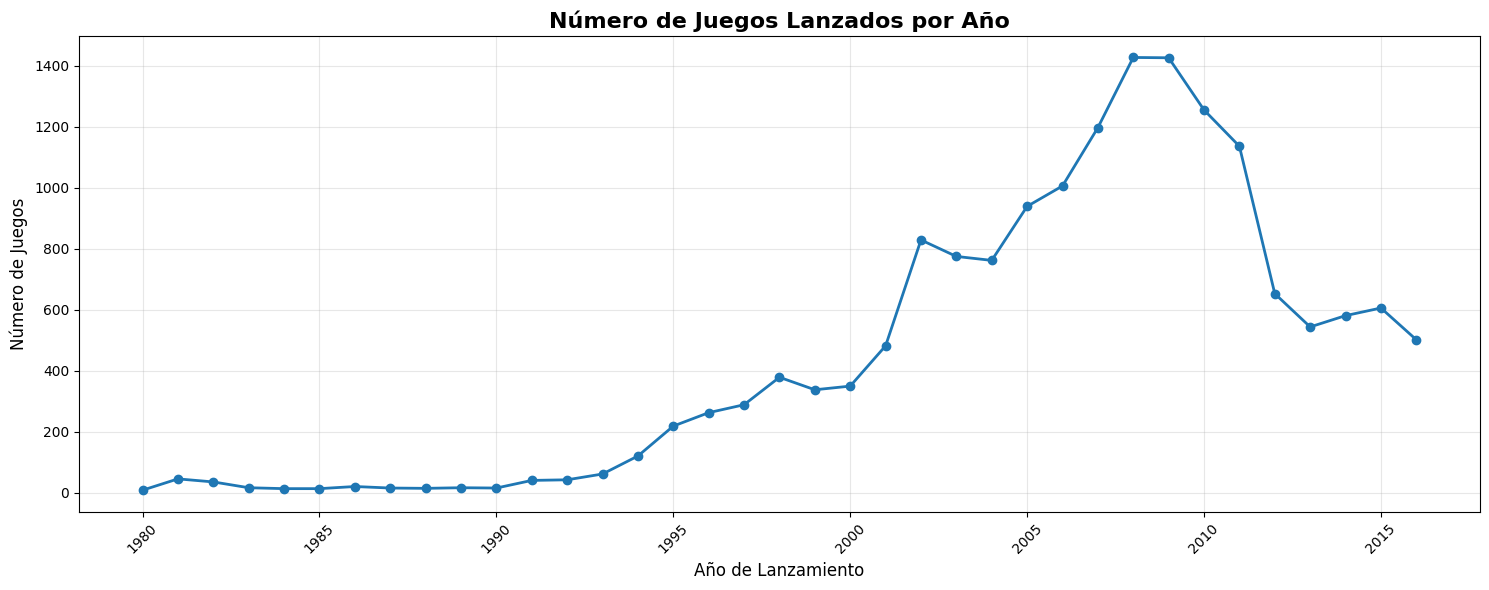


=== ANÁLISIS POR DÉCADAS ===
decade
1980.0     205
1990.0    1771
2000.0    9193
2010.0    5277
Name: year_of_release, dtype: int64


In [24]:
###VISUALIZAMOS TENDENCIAS TEMPORALES
## Crear grafico de linea para ver tendencias 
plt.figure(figsize=(15, 6))
plt.plot(games_per_year.index, games_per_year.values, marker='o', linewidth=2)
plt.title('Número de Juegos Lanzados por Año', fontsize=16, fontweight='bold')
plt.xlabel('Año de Lanzamiento', fontsize=12)
plt.ylabel('Número de Juegos', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Mostrar estadísticas por décadas
print("\n=== ANÁLISIS POR DÉCADAS ===")
df_games['decade'] = (df_games['year_of_release'] // 10) * 10
decade_stats = df_games.groupby('decade')['year_of_release'].count()
print(decade_stats)


<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


Excelente, muy bien con el gráfico. Me parece muy bien que uses un gráfico de línea, cuando la data es temporal esto es una buena decisión, ya que permite ver la tendencia de la variable mostrada. En este caso, es claro que el peak de lanzamientos quedó atrás a fines de los 2000.

</div>

In [25]:
#identifcamos periodos significativos }
print("===EVALUACION DE SIGNIFICANCIA POR PERIODO===")

# Definir umbrales para datos significativos 
min_games_threshold = 500 # minimo de datos por juego para ser significante 

# Clasificar años por cantidad dee datos 
significant_year = games_per_year[games_per_year >= min_games_threshold]
limited_years = games_per_year[games_per_year < min_games_threshold]

print(f"Años con datros significativos (>={min_games_threshold} juegos): {len(significant_year)}")
print(f"Rango de años significativos: {significant_year.index.min():.0f} - {significant_year.index.max():.0f}")

# print(f"\nAÑOS CON DATOS LIMITADOS  (<{min_games_threshold} juegos): {len(limited_years)}")
print("Primeros años con pocos datos:", limited_years.head().index.tolist())
print("Ultimos años con pocos datos:", limited_years.tail().index.tolist())

===EVALUACION DE SIGNIFICANCIA POR PERIODO===
Años con datros significativos (>=500 juegos): 15
Rango de años significativos: 2002 - 2016
Primeros años con pocos datos: [1980.0, 1981.0, 1982.0, 1983.0, 1984.0]
Ultimos años con pocos datos: [1997.0, 1998.0, 1999.0, 2000.0, 2001.0]



- Observa cómo varían las ventas de una plataforma a otra. Elige las plataformas con las mayores ventas totales y construye una distribución basada en los datos de cada año. Busca las plataformas que solían ser populares pero que ahora no tienen ventas. ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?



===TOP PLATAFORMAS POR VENTAS TOTRALES===
Top 15 plataformas por ventas totales:


platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
Name: total_sales, dtype: float64

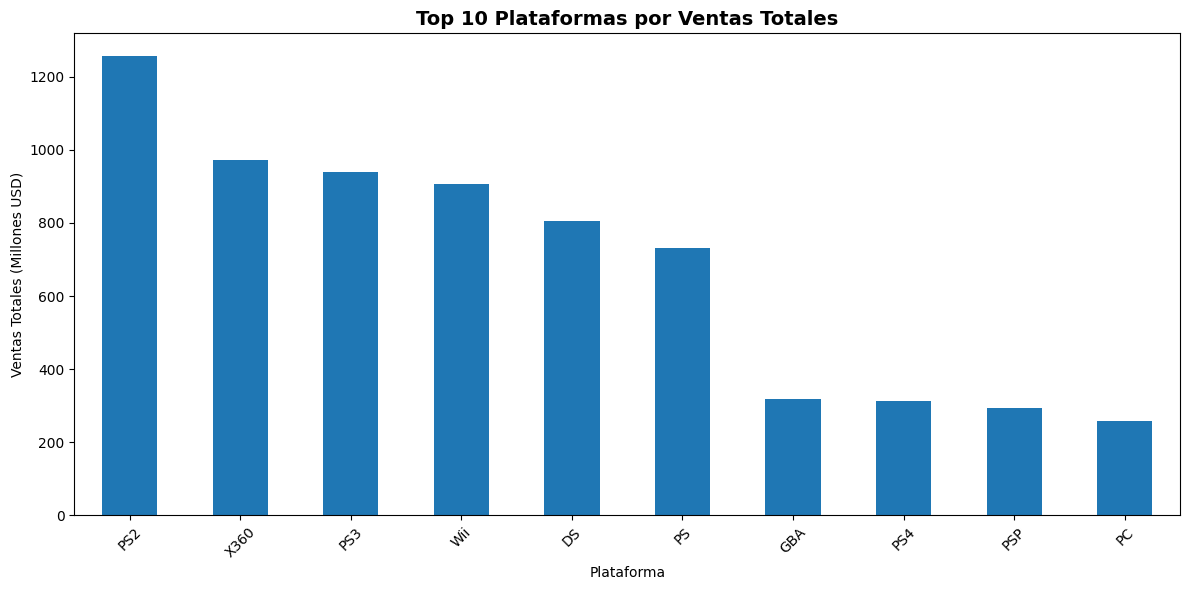

In [26]:
#IDENTIFICO LAS PLATAFORMAS CON MAYORES VENTAS TOTALES 
#Calcular ventas totakes por plataforma 
print("===TOP PLATAFORMAS POR VENTAS TOTRALES===")

platform_sales = df_games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print("Top 15 plataformas por ventas totales:")
display(platform_sales.head())

#visualizar las top platform
plt.figure(figsize=(12, 6))
platform_sales.head(10).plot(kind='bar')
plt.title('Top 10 Plataformas por Ventas Totales', fontsize=14, fontweight='bold')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Totales (Millones USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Muy bien con el gráfico, dado que las barras están ordenadas, se puede apreciar claramente las plataformas más exitosas

</div>


=== DISTRIBUCIÓN TEMPORAL DE PLATAFORMAS ===
Ventas por plataforma en primeros años:
platform           DS  GBA     PC     PS  PS2  PS3  PS4  PSP  Wii  X360
year_of_release                                                        
1985.0           0.02  0.0   0.04   0.00  0.0  0.0  0.0  0.0  0.0   0.0
1988.0           0.00  0.0   0.03   0.00  0.0  0.0  0.0  0.0  0.0   0.0
1992.0           0.00  0.0   3.03   0.00  0.0  0.0  0.0  0.0  0.0   0.0
1994.0           0.00  0.0  12.87   6.03  0.0  0.0  0.0  0.0  0.0   0.0
1995.0           0.00  0.0   4.22  35.96  0.0  0.0  0.0  0.0  0.0   0.0


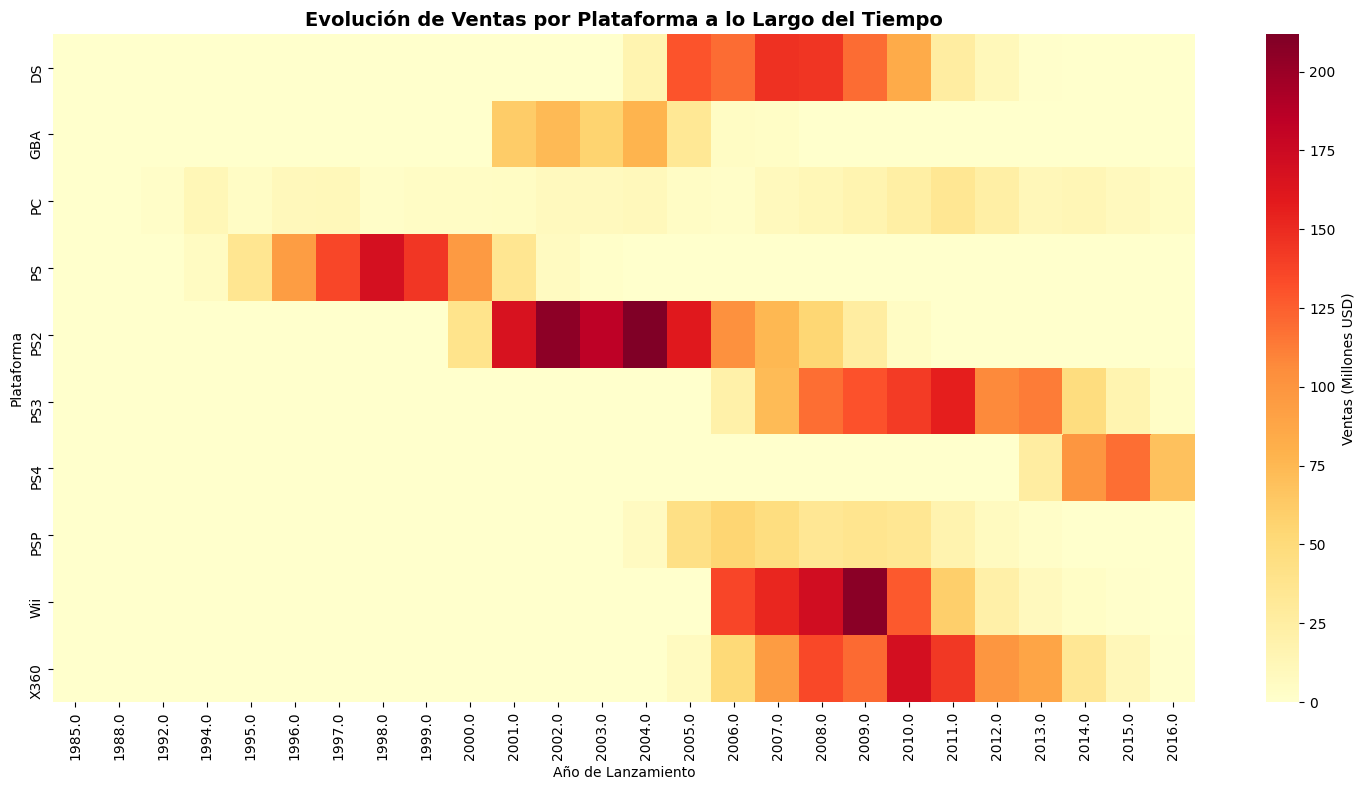

In [27]:
### ANALIZO LA DISTRIBUCION TEMPORAL DE PLATAFORMAS 

print("\n=== DISTRIBUCIÓN TEMPORAL DE PLATAFORMAS ===")

# Seleccionar top 10 plataformas para análisis detallado
top_platforms = platform_sales.head(10).index.tolist()

# Crear tabla pivote: años vs plataformas
platform_year_sales = df_games[df_games['platform'].isin(top_platforms)].groupby(
    ['year_of_release', 'platform'])['total_sales'].sum().unstack(fill_value=0)

# Mostrar primeros años
print("Ventas por plataforma en primeros años:")
print(platform_year_sales.head())

# Crear heatmap para visualizar patrones temporales
plt.figure(figsize=(15, 8))
sns.heatmap(platform_year_sales.T, cmap='YlOrRd', cbar_kws={'label': 'Ventas (Millones USD)'})
plt.title('Evolución de Ventas por Plataforma a lo Largo del Tiempo', fontsize=14, fontweight='bold')
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Plataforma')
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Excelente, muy buen gráfico, permite apreciar el periodo de vida de cada consola, incluyendo su auge y luego caída.

</div>

- Busca las plataformas que solían ser populares pero que ahora no tienen ventas. ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?

In [28]:
# Analicemos las columnas disponibles
print("Columnas disponibles:")
print(df_games.columns.tolist())
print("\nPrimeras filas para ver la estructura:")
print(df_games['year_of_release'].dtype)
display(df_games.head())


Columnas disponibles:
['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating', 'total_sales', 'decade']

Primeras filas para ver la estructura:
float64


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales,decade
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54,2000.0
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24,1980.0
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52,2000.0
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77,2000.0
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38,1990.0


In [29]:
# ANALIZANDO DESDE EL 1998


# Filtrar datos desde 1998 en adelante
#convierto en int la columna year_of_release
#df_games['year_of_release'] = df_games['year_of_release'].astype('Int64')
# Filtrar datos desde 1998 en adelante


df_desde_1998 = df_games[df_games['year_of_release'] >= 1998].copy()

# 1. Identificar el primer y último año de cada plataforma
ciclo_vida_plataformas = df_desde_1998.groupby('platform')['year_of_release'].agg(['min', 'max']).reset_index()
ciclo_vida_plataformas.columns = ['platform', 'primer_año', 'ultimo_año']

# Calcular duración del ciclo de vida
ciclo_vida_plataformas['duracion_años'] = ciclo_vida_plataformas['ultimo_año'] - ciclo_vida_plataformas['primer_año'] + 1

# Clasificar estado de la plataforma (asumiendo que 2016 es el último año de datos)
ciclo_vida_plataformas['estado'] = ciclo_vida_plataformas['ultimo_año'].apply(
    lambda x: 'activa' if x >= 2015 else 'extinta'
)

print("Ciclo de vida de plataformas desde 1998:")
print(ciclo_vida_plataformas.sort_values('primer_año'))

###Análisis de patrones de aparición y desaparición
# 2. Analizar patrones de aparición por década
ciclo_vida_plataformas['decada_aparicion'] = (ciclo_vida_plataformas['primer_año'] // 10) * 10

apariciones_por_decada = ciclo_vida_plataformas.groupby('decada_aparicion').size()
print("\nNuevas plataformas por década:")
print(apariciones_por_decada)

# 3. Tiempo promedio de vida de plataformas extintas
plataformas_extintas = ciclo_vida_plataformas[ciclo_vida_plataformas['estado'] == 'extinta']
tiempo_vida_promedio = plataformas_extintas['duracion_años'].mean()

print(f"\nTiempo promedio de vida de plataformas extintas: {tiempo_vida_promedio:.1f} años")
display(ciclo_vida_plataformas.head(10))

Ciclo de vida de plataformas desde 1998:
   platform  primer_año  ultimo_año  duracion_años   estado
8        PS      1998.0      2003.0            6.0  extinta
1        DC      1998.0      2008.0           11.0  extinta
14      SAT      1998.0      1999.0            2.0  extinta
3        GB      1998.0      2001.0            4.0  extinta
15     SNES      1998.0      1999.0            2.0  extinta
7        PC      1998.0      2016.0           19.0   activa
6       N64      1998.0      2002.0            5.0  extinta
16       WS      1999.0      2001.0            3.0  extinta
4       GBA      2000.0      2007.0            8.0  extinta
9       PS2      2000.0      2011.0           12.0  extinta
20       XB      2000.0      2008.0            9.0  extinta
5        GC      2001.0      2007.0            7.0  extinta
12      PSP      2004.0      2015.0           12.0   activa
2        DS      2004.0      2013.0           10.0  extinta
19     X360      2005.0      2016.0           12.0   activa

,platform,primer_año,ultimo_año,duracion_años,estado,decada_aparicion
0,3DS,2011.0,2016.0,6.0,activa,2010.0
1,DC,1998.0,2008.0,11.0,extinta,1990.0
2,DS,2004.0,2013.0,10.0,extinta,2000.0
3,GB,1998.0,2001.0,4.0,extinta,1990.0
4,GBA,2000.0,2007.0,8.0,extinta,2000.0
5,GC,2001.0,2007.0,7.0,extinta,2000.0
6,N64,1998.0,2002.0,5.0,extinta,1990.0
7,PC,1998.0,2016.0,19.0,activa,1990.0
8,PS,1998.0,2003.0,6.0,extinta,1990.0
9,PS2,2000.0,2011.0,12.0,extinta,2000.0


<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien hecho! Muy bien con la aplicación de agrupaciones para encontrar los primeros y últimos años de cada consola. Así, tenemos una medida precisa de sus años de vida de uso.

</div>

In [30]:
#ciclo_vida_plataformas[['primer_año','ultimo_año']] = ciclo_vida_plataformas[['primer_año','ultimo_año']].apply(pd.to_datetime)

In [31]:
#ciclo_vida_plataformas[['primer_año','ultimo_año']].dtypes

In [32]:
#ciclo_vida_plataformas['primer_año'] = pd.to_datetime(ciclo_vida_plataformas['primer_año'], format='%Y')
#ciclo_vida_plataformas['ultimo_año'] = pd.to_datetime(ciclo_vida_plataformas['ultimo_año'], format='%Y')

In [33]:
ciclo_vida_plataformas['decada_aparicion'] = ciclo_vida_plataformas['decada_aparicion'].astype(int)

In [34]:
plataformas_ciclo = ciclo_vida_plataformas['platform'].head(21).values
display
(ciclo_vida_plataformas.head(21))

,platform,primer_año,ultimo_año,duracion_años,estado,decada_aparicion
0,3DS,2011.0,2016.0,6.0,activa,2010
1,DC,1998.0,2008.0,11.0,extinta,1990
2,DS,2004.0,2013.0,10.0,extinta,2000
3,GB,1998.0,2001.0,4.0,extinta,1990
4,GBA,2000.0,2007.0,8.0,extinta,2000
5,GC,2001.0,2007.0,7.0,extinta,2000
6,N64,1998.0,2002.0,5.0,extinta,1990
7,PC,1998.0,2016.0,19.0,activa,1990
8,PS,1998.0,2003.0,6.0,extinta,1990
9,PS2,2000.0,2011.0,12.0,extinta,2000


In [35]:
df_games['year_of_release']= df_games['year_of_release'].fillna(0).astype(int)

In [36]:
df_lifetime = pd.pivot_table(
    df_games,index='year_of_release', columns='platform', values='total_sales', aggfunc='sum'
).fillna(0)
df_lifetime = df_lifetime.iloc[1:, :]
df_lifetime

platform,2600,3DO,3DS,DC,DS,GB,GBA,GC,GEN,GG,...,SAT,SCD,SNES,TG16,WS,Wii,WiiU,X360,XB,XOne
year_of_release,,,,,,,,,,,,,,,,,,,,,
1980,11.38,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1981,35.68,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1982,28.88,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1983,5.84,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1984,0.27,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1985,0.45,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1986,0.67,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1987,1.94,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1988,0.74,0.00,0.00,0.00,0.00,1.43,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


Text(0.5, 1.0, 'CICLO DE VIDA PLATAFORMAS')

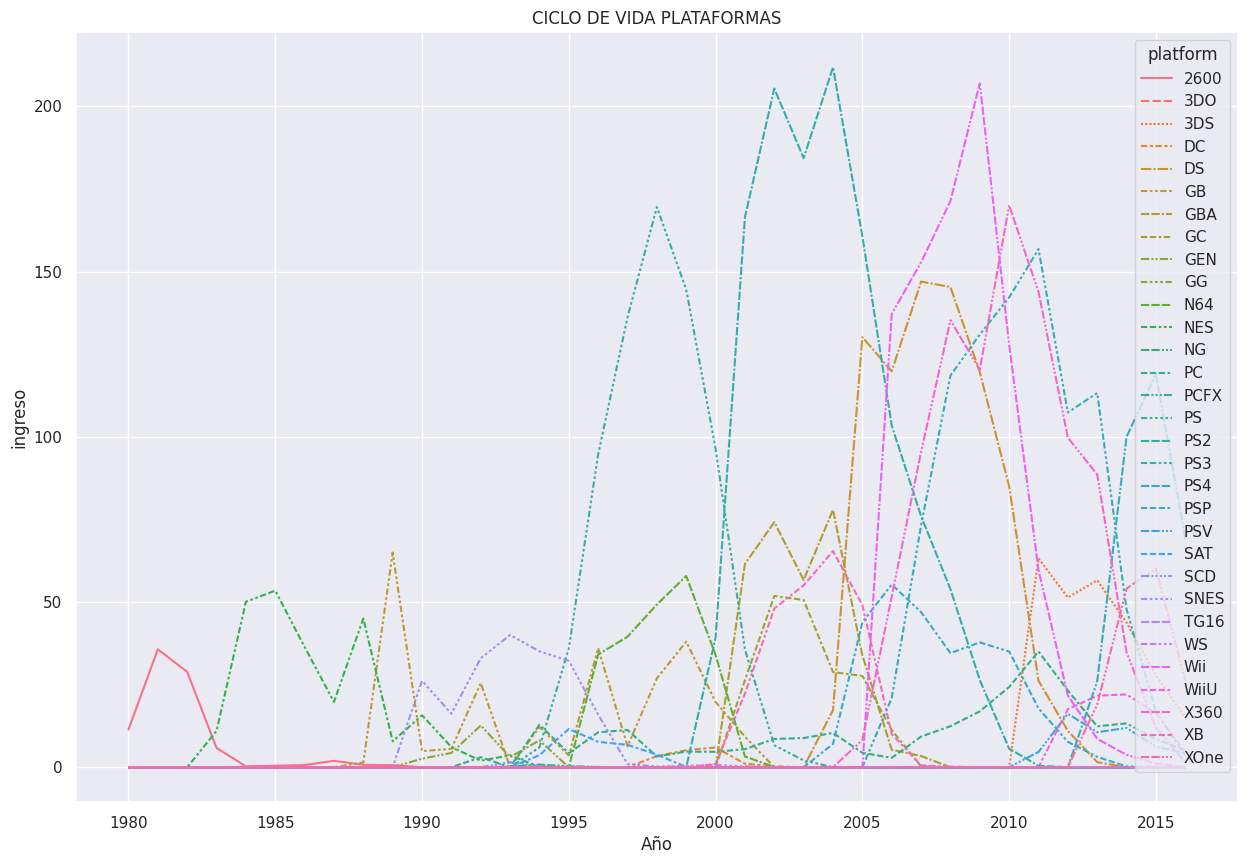

In [37]:
sns.set(rc={'figure.figsize':(15,10)})
sns.lineplot(data=df_lifetime)

plt.ylabel('ingreso')
plt.xlabel('Año')
plt.title('CICLO DE VIDA PLATAFORMAS')


In [38]:
### CALCULO LAS VENTAS POTR PLATAFORMAS TOTALES 
# Agrupo por plataforma y sumo las ventas 

ventas_por_plataforma = df_games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print("Ventas totales por plataforma:")
print(ventas_por_plataforma.head(10))


Ventas totales por plataforma:
platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
Name: total_sales, dtype: float64


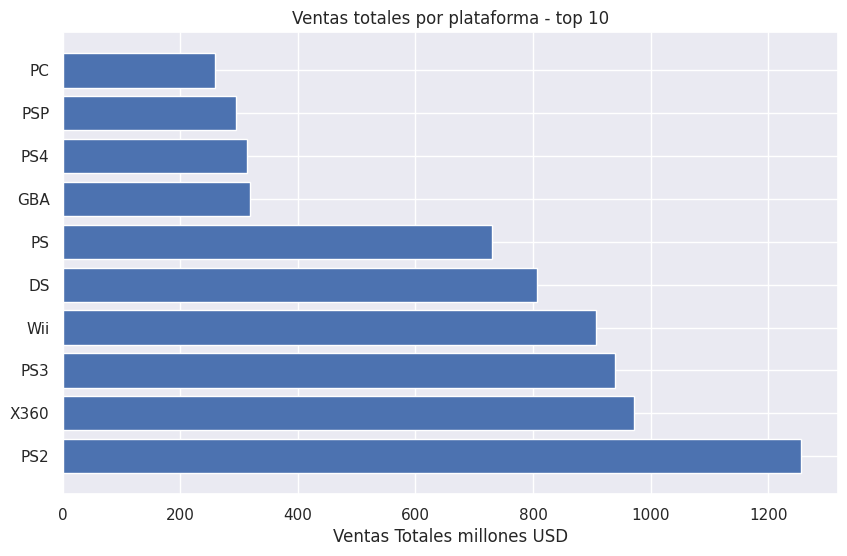

In [39]:
### VISUALIZACUIONES PARA COMPARAR PLATAFORMAS 
import matplotlib.pyplot as plt

#top 10 plataformas 
top_plataformas = ventas_por_plataforma.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_plataformas.index, top_plataformas.values)
plt.xlabel('Ventas Totales millones USD')
plt.title('Ventas totales por plataforma - top 10')
plt.show()


- Observa cómo varían las ventas de una plataforma a otra. Elige las plataformas con las mayores ventas totales y construye una distribución basada en los datos de cada año. Busca las plataformas que solían ser populares pero que ahora no tienen ventas. ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?

<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


Correcto, nmuy buien con el gráfico, es similar al mapa de calor pero con otra forma de visualización


</div>

- Segun el grafico cada plataformas a tenido sus picos entre popularidad y caida en promedio de diez años.

- Determina para qué período debes tomar datos. Para hacerlo mira tus respuestas a las preguntas anteriores. Los datos deberían permitirte construir un modelo para 2017.
Trabaja solo con los datos que consideras relevantes. Ignora los datos de años anteriores.

In [40]:
### FILTRO LOS DATOS PARA EL PERIODO SELECCIONADO

## FILTRO LOS DATOS DESDE EL 2005 EN ADELANTE 
#games_filtered = df_games[df_games['year_of_release'] >= 2005].copy()
### TOMANDO EN CUENTA EL COMENTARIO DE OSCAR HARE EL ANALIZIS CON FECHA DIFERENTE (2012+)
games_filtered = df_games[df_games['year_of_release'] >= 2012].copy()

print(f"Datos originales: {len(df_games)} juegos")
print(f"Datos filtrados (2012+): {len(games_filtered)} juegos")
print(f"Periodo de datos: {games_filtered['year_of_release'].min()} - {games_filtered['year_of_release'].max()}")


Datos originales: 16715 juegos
Datos filtrados (2012+): 2886 juegos
Periodo de datos: 2012 - 2016


<div class="alert alert-block alert-warning">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

El objetivo de la data a analizar posteriormente es que sea data que sirva para proyectar el 2017. En ese sentido, no se puede utilizar data muy antigua, ya que eso incluiría consolas que ya no existen y tendencias que ya no se repetirán para l
as consolas aún vigentes. En general, un mínimo de 2 años es suficiente y hasta 4 años puede ser útil. Tomar más años provocaría el problema que menciono.
    
El periodo de tiempo escogido no es el ideal, pero tampoco está tan mal, no hay problema con que lo dejes así para este notebook, pero ten en cuenta que para industrias muy cambiantes, probablemente 3 o 4 años de data histórica ya es suficiente y 5 años es demasiado.

</div>

In [41]:
### EN ESTE PASO ANALIZO LAS PLATAFORMAS LIDERES EN EL PERIODO QUE HE SELECCIONADO ( 20005 - 2016)

## VENTAS TOTALES POR PLATAFORMA DEL 2005 AL 2016

#games_filtered = df_games[df_games['year_of_release'] >= 2005].copy()


#print("Top 10 plataformas por ventas totales (2005+):")

#print(ventas_plataforma_filtrado.head(10))


In [42]:
### ### EN ESTE PASO ANALIZO LAS PLATAFORMAS LIDERES EN EL PERIODO QUE HE SELECCIONADO ( 2012 - 2016) CAMBIA REALIZADO POR SUGERENCIA DE MI REVISOR 

## VENTAS TOTALES POR PLATAFORMA DEL 2012 AL 2016
games_filtered = df_games[(df_games['year_of_release'] >= 2012) & (df_games['year_of_release'] <= 2016)]
ventas_plataforma_filtrado = games_filtered.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

print("Plataformas lideres en ventas (2012-2016):")
print(ventas_plataforma_filtrado.head(10))


Plataformas lideres en ventas (2012-2016):
platform
PS4     314.14
PS3     288.79
X360    236.54
3DS     194.61
XOne    159.32
WiiU     82.19
PC       62.65
PSV      49.18
Wii      35.37
DS       12.55
Name: total_sales, dtype: float64


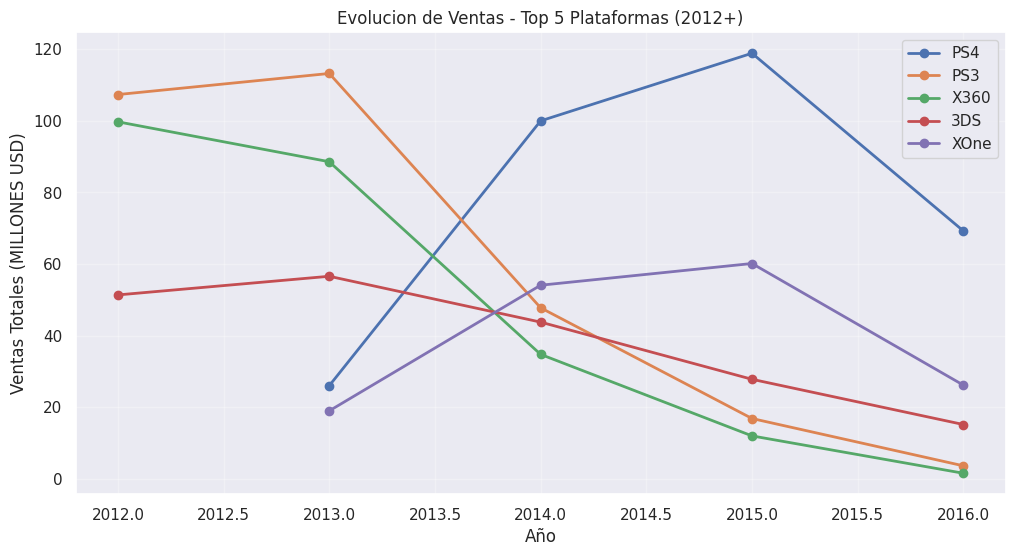

In [43]:
### ANALIZO CRECIMIENTO Y DECLIVE

## VENTAS POR AòO Y PLATAFORMA 
ventas_año_plataforma = games_filtered.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index()

# VISUALIZO EVOLUCION DE LAS TOP 5 PLATAFORMAS 
top_5_plataformas = ventas_plataforma_filtrado.head(5).index

plt.figure(figsize=(12, 6))

for plataforma in top_5_plataformas:
    data = ventas_año_plataforma[ventas_año_plataforma['platform'] == plataforma]
    plt.plot(data['year_of_release'], data['total_sales'], marker='o', label=plataforma, linewidth=2)

plt.xlabel('Año')
plt.ylabel('Ventas Totales (MILLONES USD)')
plt.title("Evolucion de Ventas - Top 5 Plataformas (2012+)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


- Las plataformas PS3 Y X360, que hace 4 años tenian ventas por encima de los 100 millones en el 2012, son las que representan menos ventas en 2016,
tambien vemos que PS4 que es la que mas ventas tiene en 2016 tuvo su pico mas alto de ventas en 2015 con 120 milliones, en 2016 sus ventas son casi de la mitad y van bajan

In [44]:
### ANALIZO VENTAS TOTALES POR PLATAFORMA

#Ventas totales por plataforma (datos filtrados 2005+)
ventas_totales_plataforma = games_filtered.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

print("Top 10 plataformas por ventas totales:")
print(ventas_totales_plataforma.head(10))


Top 10 plataformas por ventas totales:
platform
PS4     314.14
PS3     288.79
X360    236.54
3DS     194.61
XOne    159.32
WiiU     82.19
PC       62.65
PSV      49.18
Wii      35.37
DS       12.55
Name: total_sales, dtype: float64


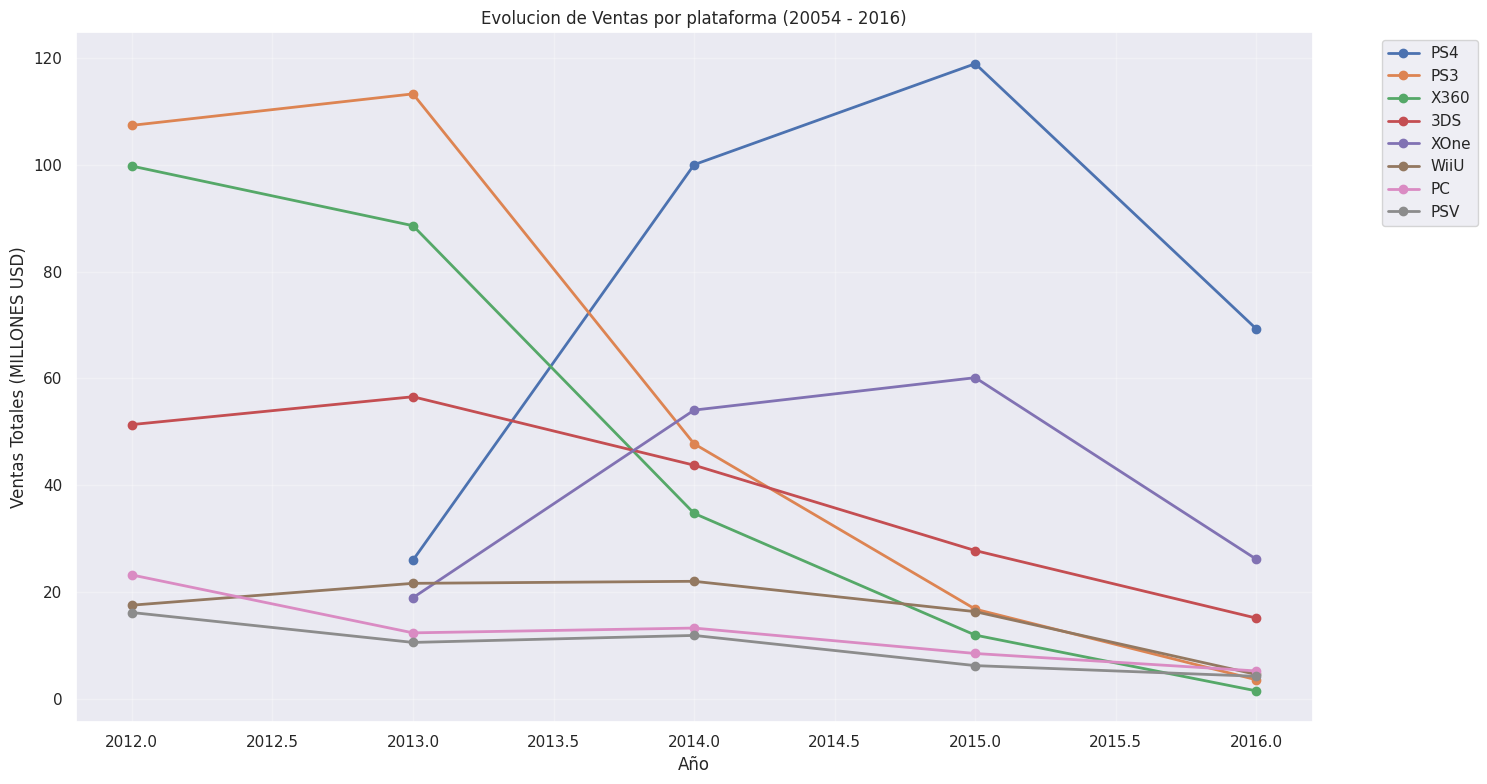

In [45]:
### VISUALIZO EVOLUCION DE LAS TOP N8 PLATAFORMAS
top_8_plataformas = ventas_totales_plataforma.head(8).index

plt.figure(figsize=(15, 8))
for plataforma in top_8_plataformas:
    data = ventas_año_plataforma[ventas_año_plataforma['platform'] == plataforma]
    plt.plot(data['year_of_release'], data['total_sales'], marker='o', label=plataforma, linewidth=2)

plt.xlabel('Año')
plt.ylabel('Ventas Totales (MILLONES USD)')
plt.title("Evolucion de Ventas por plataforma (20054 - 2016)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


- Mientras que X360, PS3, WII, DS, PS2,PSP, 3DS han bajado las ventas desde el 2014, la PS4, aunque no ha llegado a superar a las otras en ventas, si mantiene las ventas mas altas en el 2016.

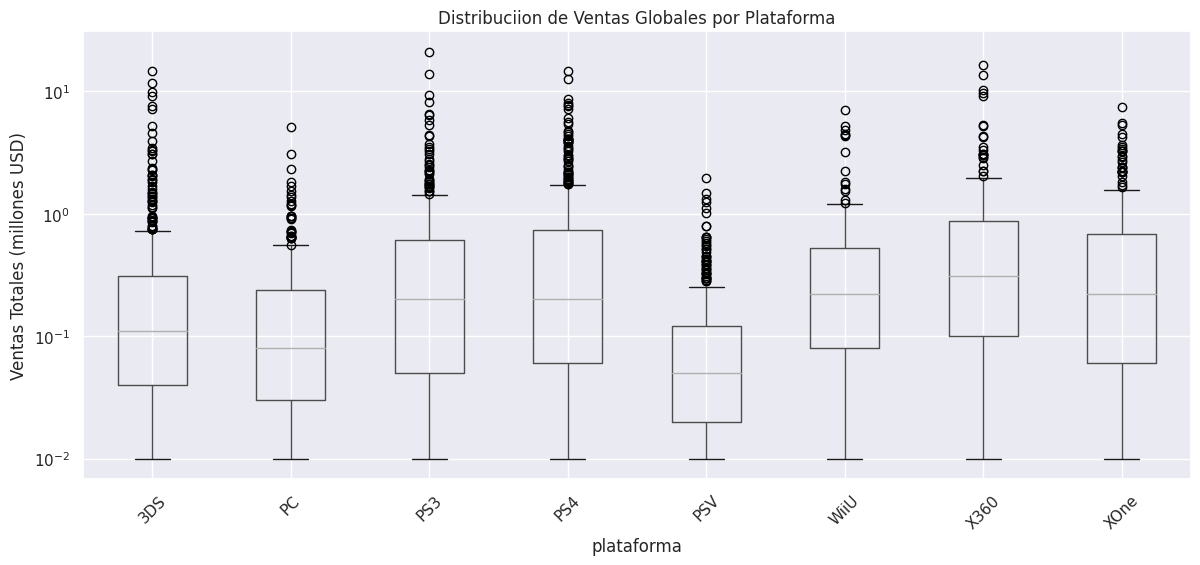

In [46]:

### CREO DIAGRAMA DE CAJA PARA VENTAS GLOBALES 

## SELECCIONO LAS TOP 6-8 PLATAFORMAS PARA EL BOXPLOT
top_plataformas_boxplot = ventas_totales_plataforma.head(8).index
games_boxplot = games_filtered[games_filtered['platform'].isin(top_plataformas_boxplot)]

plt.figure(figsize=(12, 6))
games_boxplot.boxplot(column='total_sales', by='platform', ax=plt.gca())
plt.title('Distribuciion de Ventas Globales por Plataforma')
plt.xlabel('plataforma')
plt.ylabel('Ventas Totales (millones USD)')
plt.xticks(rotation=45)
plt.suptitle('')
plt.tight_layout()
plt.yscale('log')# agrego escala logaritmica por sugerencia de mi revisor 
 
plt.show()

<div class="alert alert-block alert-warning">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien con el gráfico de boxplots, sin embargo, nota que a causa de los outliers no podemos ver la variabilidad de cada consola (las cajas son muy pequeñitas). En este caso se puede realizar el mismo gráfico pero reemplazando la escala normal por una escala logarítmica o agregando un gráfico adicional con la escala normal pero limitada a valores más pequeños (una especie de zoom al gráfico original).

</div>

In [47]:
### ANALIZO VENTAS PROMEDIO POR PLATAFORMA

#Estadisticas descriptivas por plataforma
stats_plataformas = games_boxplot.groupby('platform')['total_sales'].agg(['mean', 'median', 'std', 'count'])
stats_plataformas = stats_plataformas.round(2)
print("Estadisticas de ventas por plataforma:")
print(stats_plataformas)

Estadisticas de ventas por plataforma:
          mean  median   std  count
platform                           
3DS       0.49    0.11  1.39    396
PC        0.25    0.08  0.49    250
PS3       0.59    0.20  1.46    493
PS4       0.80    0.20  1.61    392
PSV       0.12    0.05  0.20    411
WiiU      0.56    0.22  1.06    147
X360      0.81    0.31  1.71    292
XOne      0.65    0.22  1.04    247


- Mira cómo las reseñas de usuarios y profesionales afectan las ventas de una plataforma popular (tu elección). Crea un gráfico de dispersión y calcula la correlación entre las reseñas y las ventas. Saca conclusiones.
- Teniendo en cuenta tus conclusiones compara las ventas de los mismos juegos en otras plataformas.
- Echa un vistazo a la distribución general de los juegos por género. ¿Qué se puede decir de los géneros más rentables? ¿Puedes generalizar acerca de los géneros con ventas altas y bajas?

In [48]:
### ANALISIS DE CORRELACION: RESEÑAS VS VENTAS 
## PARA HACER ESTE ANALISIS HEMOS ELEGIDO LA PLATAFORMA (PS4)

# Filtrar datos solo para PS4
ps4_games = games_filtered[games_filtered['platform'] ==  'PS4'].copy()

print(f"Juegos de PS4 en el periodo 2012+: {len(ps4_games)}")
print(f"Años disponibles: {ps4_games['year_of_release'].min()} - {ps4_games['year_of_release'].max()}")

Juegos de PS4 en el periodo 2012+: 392
Años disponibles: 2013 - 2016


In [49]:
### VERIFICAMOS DATOS DE RESEÑAS DISPONIBLES 
print("Datos de reseñas disponibles:")
print(f"User Score - Valores no nulos: {ps4_games['user_score'].notna().sum()}")
print(f"Critic Score - Valores no nulos: {ps4_games['critic_score'].notna().sum()}")

# Filtrar solo juegos con datos de reseñas completas
ps4_complete = ps4_games.dropna(subset=['user_score', 'critic_score'])
print(f"Juegos PS4 con reseñas completas: {len(ps4_complete)}")

Datos de reseñas disponibles:
User Score - Valores no nulos: 257
Critic Score - Valores no nulos: 252
Juegos PS4 con reseñas completas: 249


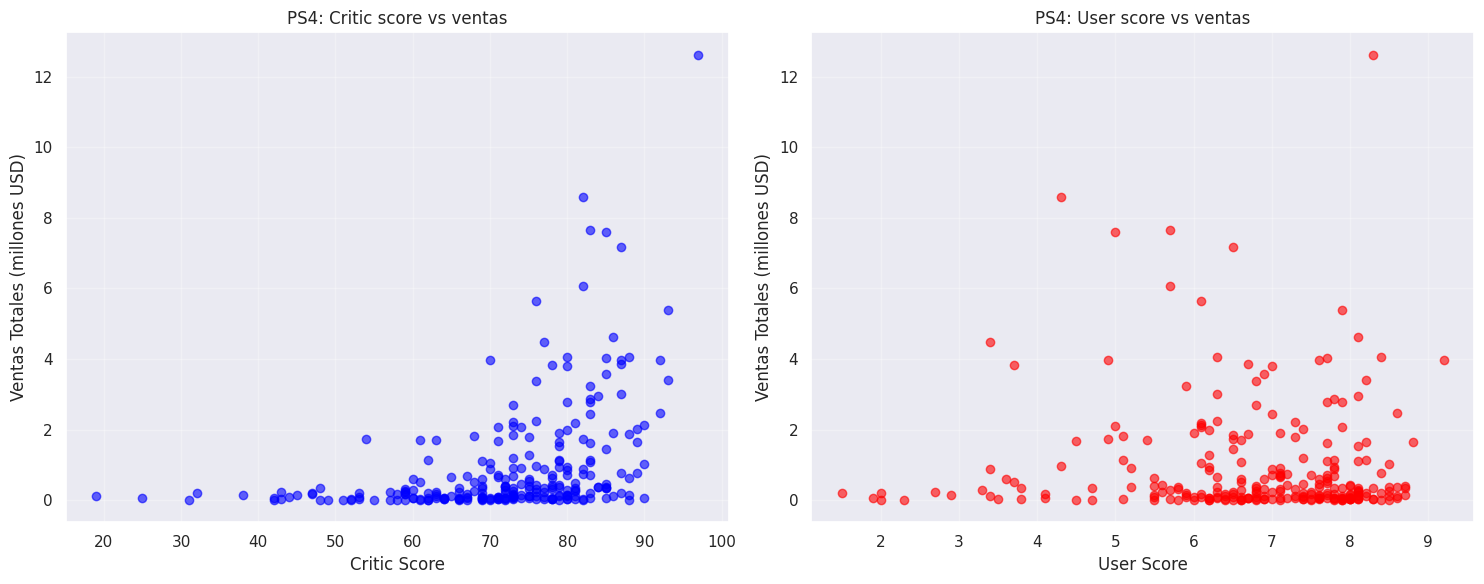

In [50]:
### GRAFICOS DE DISPERSION: CRITIC SCORE VS VENTAS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

## Critic score vs total sales 
ax1.scatter(ps4_complete['critic_score'], ps4_complete['total_sales'], alpha=0.6, color='blue')
ax1.set_xlabel('Critic Score')
ax1.set_ylabel('Ventas Totales (millones USD)')
ax1.set_title('PS4: Critic score vs ventas')
ax1.grid(True, alpha=0.3)

# User Score vs Total Sales 
ax2.scatter(ps4_complete['user_score'], ps4_complete['total_sales'], alpha=0.6,color='red')
ax2.set_xlabel('User Score')
ax2.set_ylabel('Ventas Totales (millones USD)')
ax2.set_title('PS4: User score vs ventas')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
correlacion_critic = ps4_complete['critic_score'].corr(ps4_complete['total_sales'])
correlacion_user = ps4_complete['user_score'].corr(ps4_complete['total_sales'])

print(f"Correlacion Critic Score - Ventas: {correlacion_critic:.3f}")
print(f"Correlacion User Score - Ventas: {correlacion_user:.3f}")

Correlacion Critic Score - Ventas: 0.406
Correlacion User Score - Ventas: -0.034


<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien hecho con el gráfico y el cálculo del coeficiente. Permite obtener una visión general de la correlación entre ambas variables.

</div>

In [52]:
### IDENTIFICAR JUEGOS QUE ESTAN EN MULTIPLES PLATAFORMAS 

## Encontrar juegos que estan tanto en PS4 como en otras plataformas top
juegos_ps4 = set(ps4_complete['name'].unique())

# Ver que juegos de PS4 tambien estan en otras plataformas top 
juegos_multiplataforma = games_filtered[
    (games_filtered['name'].isin(juegos_ps4)) &
    (games_filtered['platform'].isin(top_8_plataformas))].copy()

# Ver distribucion por plataforma
print("\nDistribuicion de estos juegos por plataforma:")
print(juegos_multiplataforma['platform'].value_counts())



Distribuicion de estos juegos por plataforma:
PS4     249
XOne    157
PS3     100
PC       83
X360     73
PSV      47
WiiU     26
3DS      17
Name: platform, dtype: int64


In [53]:
### COMPARAR VENTAS DEL MISMO JUEGO EN DIFERENTES PLATAFORMAS 

## Crear tabla comparativa de ventas por juego y plataforma
ventas_comparativa = juegos_multiplataforma.pivot_table(
    index='name',
    columns='platform',
    values='total_sales',
    fill_value=0
)

print("Primeros 10 juegos -ventas por plataforma:")
display(ventas_comparativa.head(10))

Primeros 10 juegos -ventas por plataforma:


platform,3DS,PC,PS3,PS4,PSV,WiiU,X360,XOne
name,,,,,,,,
7 Days to Die,0.00,0.00,0.00,0.14,0.00,0.00,0.00,0.05
Aegis of Earth: Protonovus Assault,0.00,0.00,0.02,0.02,0.03,0.00,0.00,0.00
Agatha Christie's The ABC Murders,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.01
Alien: Isolation,0.00,0.15,0.33,1.12,0.00,0.00,0.27,0.50
Angry Birds Star Wars,0.33,0.00,0.29,0.22,0.08,0.10,0.28,0.17
Anima - Gate of Memories,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.00
Arslan: The Warriors of Legend,0.00,0.00,0.05,0.09,0.00,0.00,0.00,0.01
Assassin's Creed Chronicles: China,0.00,0.00,0.00,0.04,0.00,0.00,0.00,0.00
Assassin's Creed IV: Black Flag,0.00,0.65,3.71,2.86,0.00,0.29,3.31,2.24


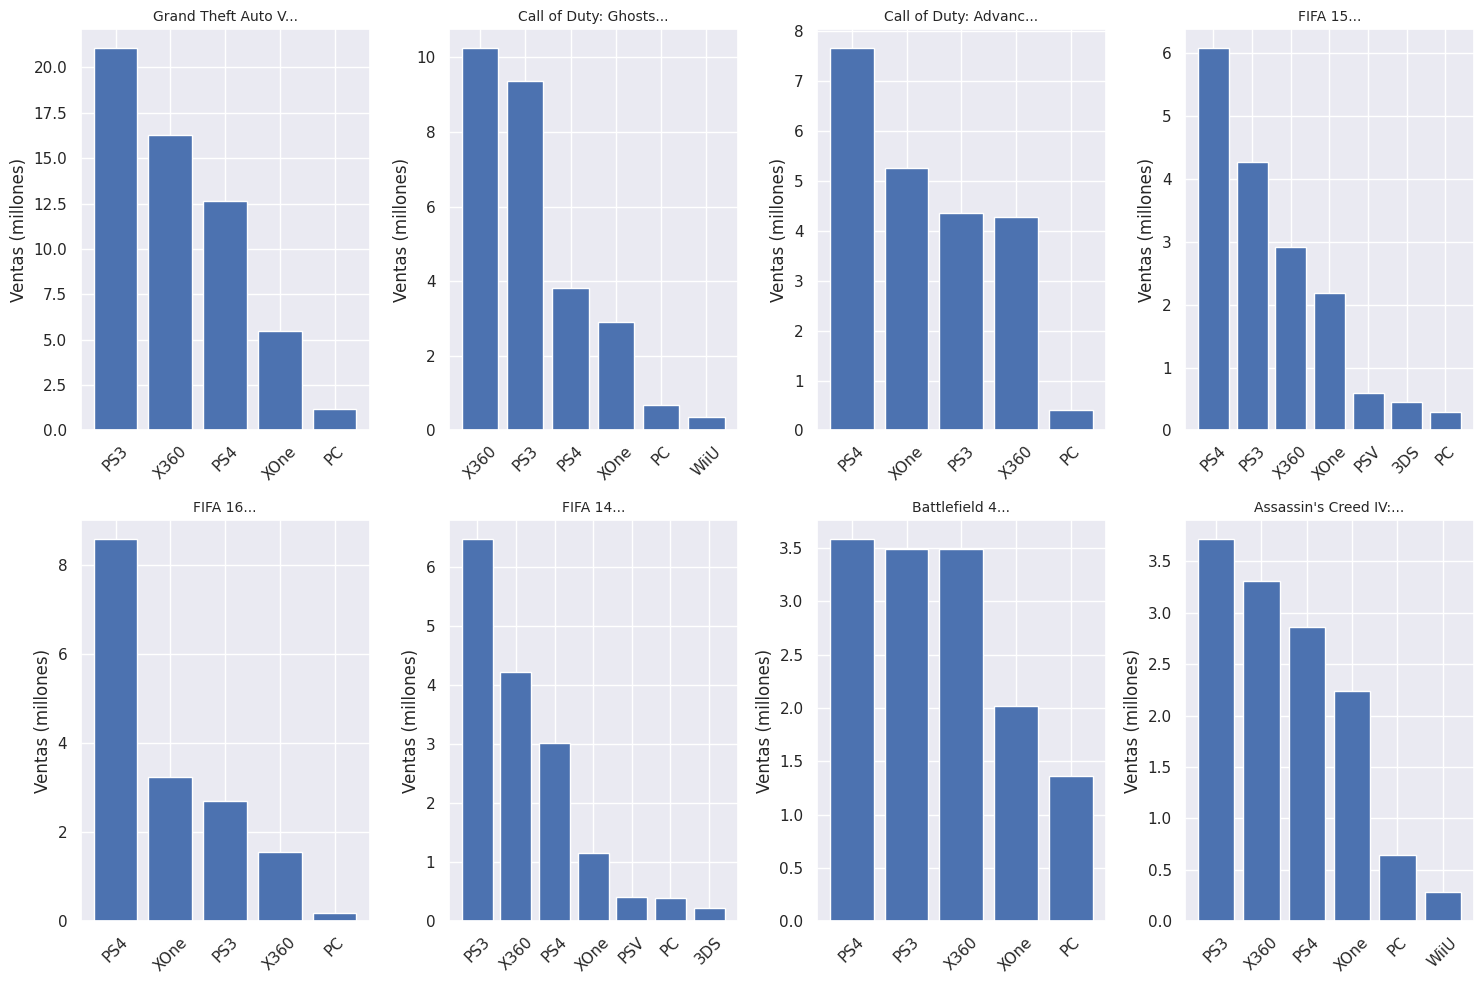

In [54]:
### VISUALIZAR COMPARACION DE VENTAS 

# SELECCIONAR ALGUNOS JUEGOS POPULARES PARA VISUALIZAR
juegos_populares = juegos_multiplataforma.groupby('name')['total_sales'].sum().sort_values(ascending=False).head(8)

plt.figure(figsize=(15, 10))
for i, juego in enumerate(juegos_populares.index):
    data_juego = juegos_multiplataforma[juegos_multiplataforma['name'] == juego]

    plt.subplot(2, 4, i+1)
    plt.bar(data_juego['platform'], data_juego['total_sales'])
    plt.title(f'{juego[:20]}...', fontsize=10)
    plt.ylabel('Ventas (millones)')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario de Revisor       </b> <a class="tocSkip"></a>

Muy bien, este análisis nos permite encontrar la competencia de cada consola, o al menos, donde han competido. El gráfico mostrado está muy bien armado, haces bien en tenerlos agrupados por juego y tener a las consolas en barras separadas

</div>

In [55]:

### ANALIZO CORRELACIONES EN OTRAS PLATAFORMAS 

## Compara correlaciones reseñas-ventas en diferentes plataformas 
correlaciones_plataformas ={}

for plataforma in top_8_plataformas:
    if plataforma == 'PS4':
        continue

    datos_plataforma = juegos_multiplataforma[
        (juegos_multiplataforma['platform'] == plataforma) &
        (juegos_multiplataforma['critic_score'].notna()) &
        (juegos_multiplataforma['user_score'].notna())
    ]

    if len(datos_plataforma) > 5: # solo si hay suficientes datos
        corr_critic = datos_plataforma['critic_score'].corr(datos_plataforma['total_sales'])
        corr_user = datos_plataforma['user_score'].corr(datos_plataforma['total_sales'])

        correlaciones_plataformas[plataforma] = {
            'critic_corr': corr_critic,
            'user_corr': corr_user,
            'n_juegos': len(datos_plataforma)
        }

print("Comparacion de correlaciones entre plataformas:")
print("Plaraforma | Critic-Ventas | User-Ventas | N° Juegos")
print("-" * 50)
print(f"PS4          | {correlacion_critic:.3f}       | {correlacion_user:.3f}         | {len(ps4_complete)}")

for plataforma, datos in correlaciones_plataformas.items():
    print(f"{plataforma:<10}     | {datos['critic_corr']:.3f}   | {datos['user_corr']:.3}         | {datos['n_juegos']}")


Comparacion de correlaciones entre plataformas:
Plaraforma | Critic-Ventas | User-Ventas | N° Juegos
--------------------------------------------------
PS4          | 0.406       | -0.034         | 249
PS3            | 0.434   | 0.0414         | 21
X360           | 0.472   | -0.145         | 21
3DS            | -0.468   | -0.85         | 6
XOne           | 0.394   | -0.15         | 138
WiiU           | 0.372   | 0.236         | 20
PC             | 0.340   | 0.0314         | 78
PSV            | 0.104   | -0.127         | 22


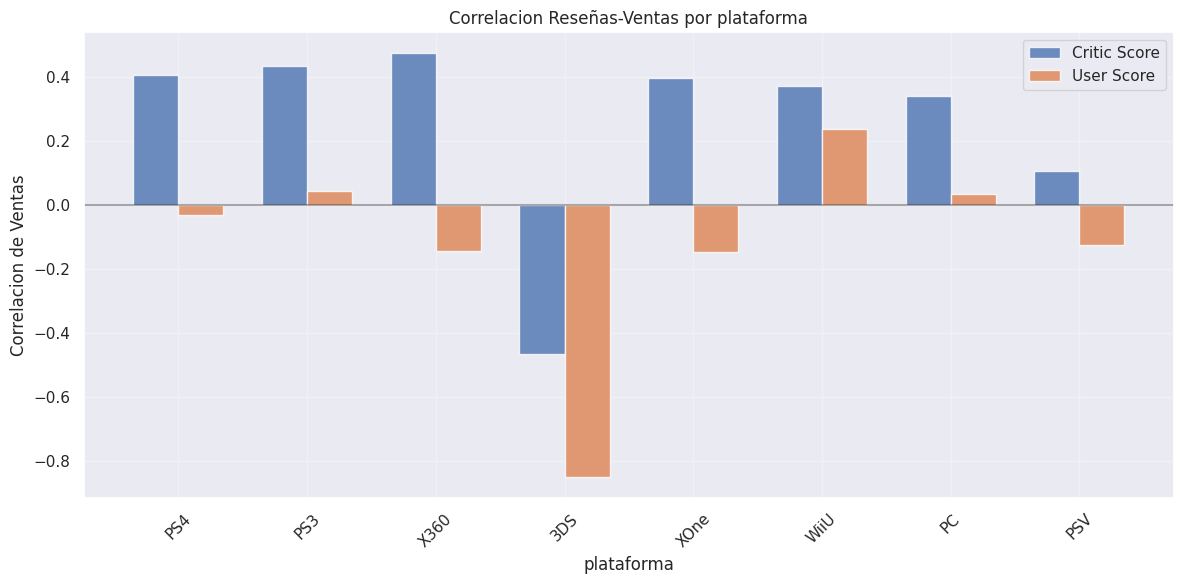

In [56]:
### VISUALIZAR CORRELACXIONES COMPARATIVAS
## Crear grafico comparativo de correlacion
plataformas_list = ['PS4'] + list(correlaciones_plataformas.keys())
critic_corrs = [correlacion_critic] + [correlaciones_plataformas[p]['critic_corr'] for p in correlaciones_plataformas.keys()]
user_corrs = [correlacion_user] + [correlaciones_plataformas[p]['user_corr'] for p in correlaciones_plataformas.keys()]

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(plataformas_list))
width = 0.35

ax.bar([i - width/2 for i in x], critic_corrs, width, label='Critic Score', alpha=0.8)
ax.bar([i + width/2 for i in x], user_corrs, width, label='User Score', alpha=0.8)

ax.set_xlabel('plataforma')
ax.set_ylabel('Correlacion de Ventas')
ax.set_title('Correlacion Reseñas-Ventas por plataforma')
ax.set_xticks(x)
ax.set_xticklabels(plataformas_list, rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

### Analisi de rentabilidad por genero

In [57]:
## Agrupo por genero 

ventas_por_genero = df_games.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
print(ventas_por_genero)
print()
ventas_promedio_genero = df_games.groupby('genre')['total_sales'].mean().sort_values(ascending=False)
print(ventas_promedio_genero)



genre
Action          1744.17
Sports          1331.27
Shooter         1052.45
Role-Playing     934.56
Platform         827.77
Misc             802.51
Racing           728.67
Fighting         447.53
Simulation       389.97
Puzzle           242.57
Adventure        237.59
Strategy         174.23
Name: total_sales, dtype: float64

genre
Platform        0.932173
Shooter         0.795503
Role-Playing    0.623872
Racing          0.583403
Sports          0.566980
Fighting        0.527126
Action          0.517711
Misc            0.458577
Simulation      0.446701
Puzzle          0.418224
Strategy        0.255095
Adventure       0.182341
Name: total_sales, dtype: float64


In [58]:
#Analisis de restabilidad por genero 
# Agrupar por genero y calcular ventas totales 
genero_analisis = df_games.groupby('genre').agg({
    'total_sales': ['sum', 'mean', 'count']
}).round(2)

#Aplanar los nombres de las columnas 
genero_analisis.columns = ['ventas_totales', 'ventas_promedio', 'cantidad_juego']
genero_analisis = genero_analisis.reset_index()

print("Analisis de rentabilidad por genero:")
display(genero_analisis.sort_values('ventas_totales', ascending=False))


Analisis de rentabilidad por genero:


,genre,ventas_totales,ventas_promedio,cantidad_juego
0,Action,1744.17,0.52,3369
10,Sports,1331.27,0.57,2348
8,Shooter,1052.45,0.80,1323
7,Role-Playing,934.56,0.62,1498
4,Platform,827.77,0.93,888
3,Misc,802.51,0.46,1750
6,Racing,728.67,0.58,1249
2,Fighting,447.53,0.53,849
9,Simulation,389.97,0.45,873
5,Puzzle,242.57,0.42,580


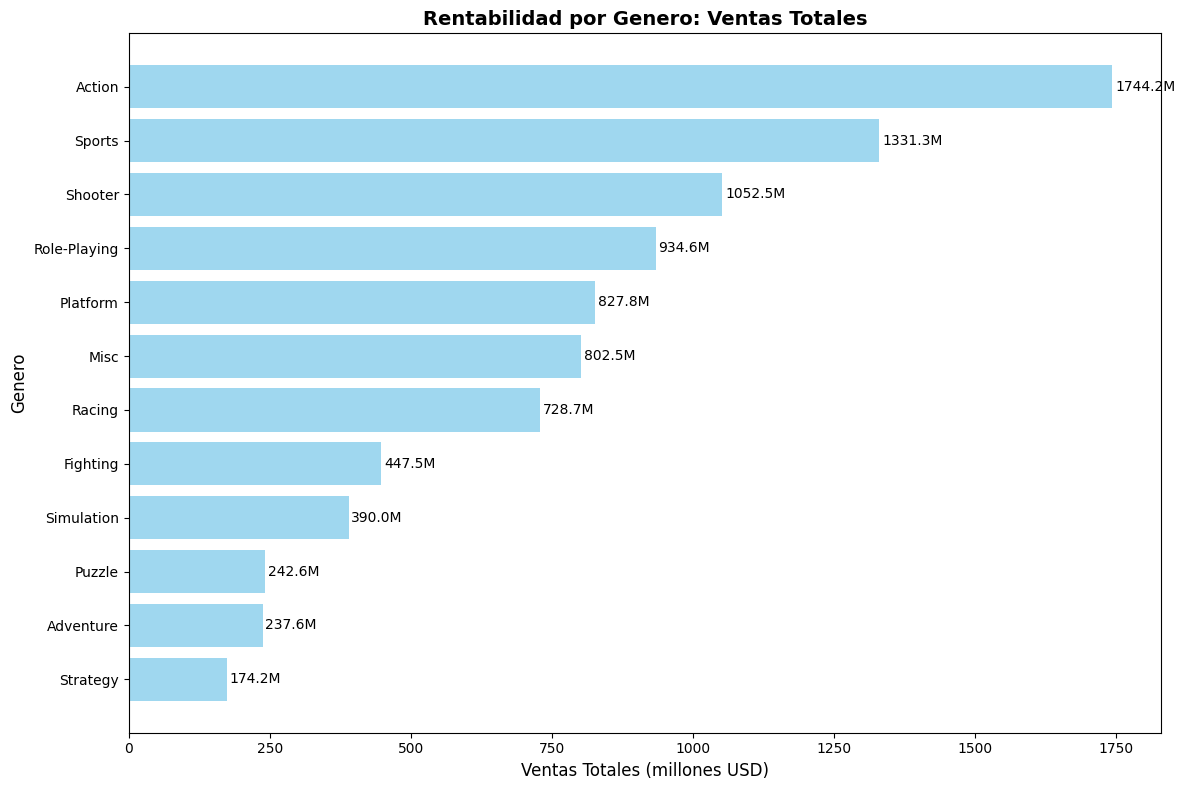

In [59]:
# configurar el estilo
plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 8))

# Ordenar por ventas totales 
genero_totales = genero_analisis.sort_values('ventas_totales', ascending=True)

# Creo el grafico de barras horizontales
bars = ax.barh(genero_totales['genre'],genero_totales['ventas_totales'],
              color='skyblue', alpha=0.8)

# Personalizar de grafico
ax.set_xlabel('Ventas Totales (millones USD)', fontsize=12)
ax.set_ylabel('Genero', fontsize=12)
ax.set_title('Rentabilidad por Genero: Ventas Totales', fontsize=14, fontweight='bold')

# Agregar valores en las barras 
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 5, bar.get_y() + bar.get_height()/2,
           f'{width:.1f}M', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

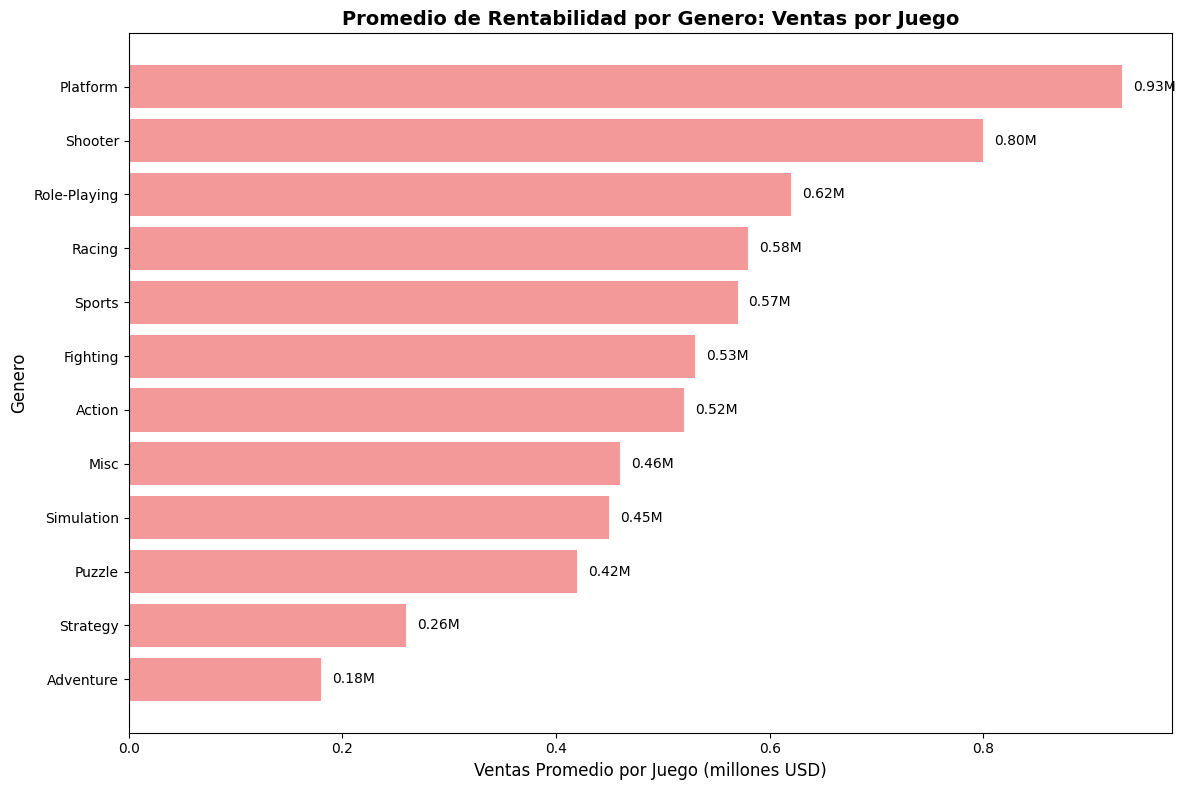

In [60]:
# grafico de ventas promedio por genero
fig, ax = plt.subplots(figsize=(12, 8))
# VENTAS PROMEDIO 
genero_promedio = genero_analisis.sort_values('ventas_promedio', ascending=True)

# Crear grafico barras horizontales 
bars = ax.barh(genero_promedio['genre'], genero_promedio['ventas_promedio'],
              color='lightcoral', alpha=0.8)

# Personalizo el grafico 
ax.set_xlabel('Ventas Promedio por Juego (millones USD)', fontsize=12)
ax.set_ylabel('Genero', fontsize=12)
ax.set_title('Promedio de Rentabilidad por Genero: Ventas por Juego', fontsize=14, fontweight='bold')

# Agregar valores en las barras 
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2,
           f'{width:.2f}M', ha='left', va='center', fontsize=10)
plt.tight_layout()
plt.show()

- he agregado la retabilidad de los generos y sus graficos sugeridos por el revisor.

<div class="alert alert-block alert-danger">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

En esta parte falta un análisis de la rentabilidad de los géneros. Analiza las ventas totales y promedio de cada género con un gráfico para cada aspecto.



</div>

<div class="alert alert-block alert-success">
<b>Comentario de Revisor  v2    </b> <a class="tocSkip"></a>

Muy bien, bien hecho al mostrar ambos gráficos, vemos que hay géneros que no venden tanto en total pero debido a que tienen pocos juegos logran un alto promedio

</div>

- Paso 4. Crea un perfil de usuario para cada región

Para cada región (NA, UE, JP) determina:

- Las cinco plataformas principales. Describe las variaciones en sus cuotas de mercado de una región a otra.
- Los cinco géneros principales. Explica la diferencia.
- Si las clasificaciones de ESRB afectan a las ventas en regiones individuales.

In [61]:
### CREO PERFILES DE USUARIO POR REGION ,analisis de las 5 plataformas principales por region

## Calcular las cinco plataformas principales por region
print("=== ANALISIS DE PLATAFORMAS POR REGION ===\n")

# plataformas principales en norteamerica (NA)
na_platforms = df_games.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
print("Top 5 plataformas en Norteamerica:")
print(na_platforms)
print()

#plataformas principales en Europa (EU)
eu_platforms = df_games.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
print("Top 5 plataformas en Europa:")
print(eu_platforms)
print()

#plataformas principales en Japon (JP)
jp_platforms = df_games.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)
print("Top 5 plataformas en japon:")
print(jp_platforms)
print()

=== ANALISIS DE PLATAFORMAS POR REGION ===

Top 5 plataformas en Norteamerica:
platform
X360    602.47
PS2     583.84
Wii     496.90
PS3     393.49
DS      382.40
Name: na_sales, dtype: float64

Top 5 plataformas en Europa:
platform
PS2     339.29
PS3     330.29
X360    270.76
Wii     262.21
PS      213.61
Name: eu_sales, dtype: float64

Top 5 plataformas en japon:
platform
DS      175.57
PS      139.82
PS2     139.20
SNES    116.55
3DS     100.67
Name: jp_sales, dtype: float64



In [62]:
df_games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales,decade
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54,2000.0
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24,1980.0
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52,2000.0
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77,2000.0
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38,1990.0


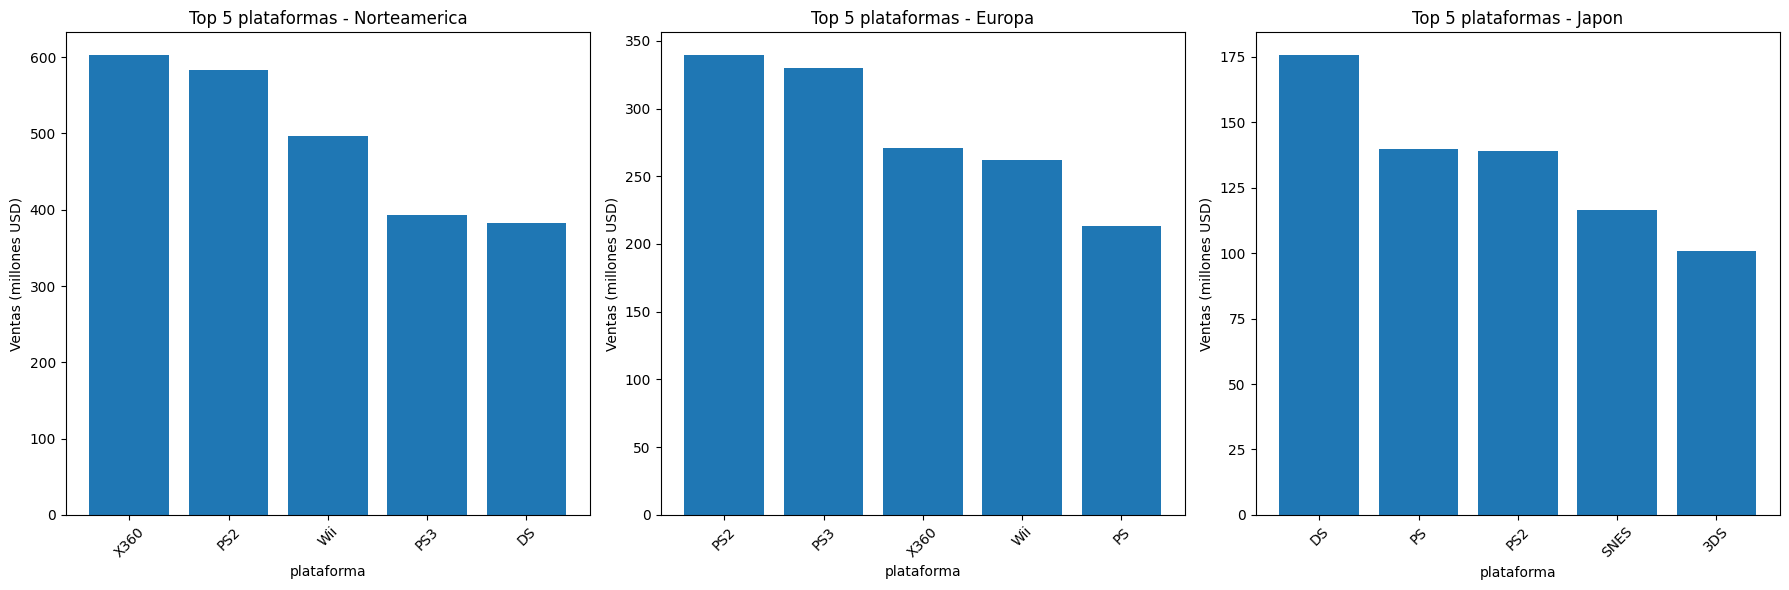

In [63]:
### VISUALIZACION COMPARATIVA DE PLATAFORMAS 

plataformas_comparacion = pd.DataFrame({
    'NA': na_platforms,
    'EU': eu_platforms,
    'JP': jp_platforms   
}).fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Norteamerica
axes[0].bar(range(len(na_platforms)), na_platforms.values)
axes[0].set_title('Top 5 plataformas - Norteamerica')
axes[0].set_xlabel('plataforma')
axes[0].set_ylabel('Ventas (millones USD)')
axes[0].set_xticks(range(len(na_platforms)))
axes[0].set_xticklabels(na_platforms.index, rotation=45)

#plt.tight_layout()
#plt.show()

# Europa
axes[1].bar(range(len(eu_platforms)), eu_platforms.values)
axes[1].set_title('Top 5 plataformas - Europa')
axes[1].set_xlabel('plataforma')
axes[1].set_ylabel('Ventas (millones USD)')
axes[1].set_xticks(range(len(eu_platforms)))
axes[1].set_xticklabels(eu_platforms.index, rotation=45)

#plt.tight_layout()
#plt.show()


# Japon
axes[2].bar(range(len(jp_platforms)), jp_platforms.values)
axes[2].set_title('Top 5 plataformas - Japon')
axes[2].set_xlabel('plataforma')
axes[2].set_ylabel('Ventas (millones USD)')
axes[2].set_xticks(range(len(jp_platforms)))
axes[2].set_xticklabels(jp_platforms.index, rotation=45)

plt.tight_layout()
plt.show()

In [64]:
#primero exploro las clasificaciones ESRB disponibles
print("Clasificaciones ESRB en el dataset")
print(df_games['rating'].value_counts())
print()

# Verificar valores nulos 
print("Valores nulos en rating:", df_games['rating'].isnull().sum())

Clasificaciones ESRB en el dataset
E       3993
T       2961
M       1563
E10+    1420
EC         8
AO         1
Name: rating, dtype: int64

Valores nulos en rating: 6769


In [65]:
# VERIFICO QUÉ CLASIFICACIONES ESRB TENGO
print("===EXPLORACIÓN DE CLASIFICACIONES ESRB===")
print("Clasificaciones disponibles:")
print(df_games['rating'].value_counts())
print()
print("Valores nulos:", df_games['rating'].isnull().sum())


===EXPLORACIÓN DE CLASIFICACIONES ESRB===
Clasificaciones disponibles:
E       3993
T       2961
M       1563
E10+    1420
EC         8
AO         1
Name: rating, dtype: int64

Valores nulos: 6769


In [66]:
df_games_clean = df_games.dropna(subset=['rating'])
print(f"Datos originales: {len(df_games)} filas")
print(f"Datos despues de limpiar: {len(df_games_clean)} filas")

Datos originales: 16715 filas
Datos despues de limpiar: 9946 filas


In [67]:
### CALCULO VENTAS PROMEDIO POR CLASIFICACION ESRB EN CADA REGION

## Agrupar por rating y calcular las ventas promedio por region

esrb_analysis = df_games_clean.groupby('rating').agg({
    'na_sales': 'mean',
    'eu_sales': 'mean',
    'jp_sales': 'mean'
}).round(2)

print("=== VENTAS PROMEDIO POR CLASIFICACION ESRB===")
print(esrb_analysis)

=== VENTAS PROMEDIO POR CLASIFICACION ESRB===
        na_sales  eu_sales  jp_sales
rating                              
AO          1.26      0.61      0.00
E           0.32      0.18      0.05
E10+        0.25      0.13      0.03
EC          0.19      0.01      0.00
M           0.48      0.31      0.04
T           0.26      0.14      0.05


In [68]:
df_games_clean.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales,decade
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54,2000.0
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52,2000.0
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77,2000.0
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E,29.80,2000.0
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E,28.91,2000.0


In [69]:
### MOSTRAS LAS PRIMERAS FILAS PARA VERIFICAR LA ESTRUCTURA
print("=== VERIFICAR DATOS===")
print("Primeras 5 filas del dataset:")
print(df_games[['platform', 'rating', 'na_sales','eu_sales','jp_sales']].head())
print()

# Verificar tipos de datos
print("tipos de datos:")
print(df_games[['platform', 'rating', 'na_sales','eu_sales','jp_sales']].dtypes)

=== VERIFICAR DATOS===
Primeras 5 filas del dataset:
  platform rating  na_sales  eu_sales  jp_sales
0      Wii      E     41.36     28.96      3.77
1      NES    NaN     29.08      3.58      6.81
2      Wii      E     15.68     12.76      3.79
3      Wii      E     15.61     10.93      3.28
4       GB    NaN     11.27      8.89     10.22

tipos de datos:
platform     object
rating       object
na_sales    float64
eu_sales    float64
jp_sales    float64
dtype: object


<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien hecho, muy bien con la comparación entre las regiones. Es importante revisar diferentes dimensiones entre cada uno, esto revela puntos importantes de segmentación que podrían ser beneficiosos para un modelo de predicción. Por ejemplo, observamos que Japón es muy diferente respecto a las otras regiones en varios aspectos, tal vez esto justifique diferentes modelos o reglas para esta región.
    
</div>

- Paso 5. Prueba las siguientes hipótesis:

— Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

— Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

Establece tu mismo el valor de umbral alfa.

Explica:

— Cómo formulaste las hipótesis nula y alternativa.

— Qué criterio utilizaste para probar las hipótesis y por qué.

- Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

In [70]:
### filtro los datos de XBOX ONE Y PC con user score 
## Filtrar datos para xbox one
xbox_data = df_games[df_games['platform'] == 'XOne']
#filtro datos para xbox
pc_data = df_games[df_games['platform'] == 'PC']

In [71]:



### EXTRAIGO LAS CALIFICACIONJES DE USUARIOS
# Obtener solo las calificaciones de usuarios parea cada plataforma

x



range(0, 8)

In [72]:
xbox_user_scores = xbox_data['user_score']
pc_user_scores = pc_scores = pc_data['user_score']

In [73]:
xbox_scores_clean = xbox_user_scores.dropna()
pc_scores_clean = pc_user_scores.dropna()

In [74]:



# ESTABLECENMOS LAS HIPOTESIS 
#- Hipotesis nula(H0): Las calificaciones promedio de usuarios son iguales para Xbox One y PC
#- Hipotesis alternativa(H1): Las calificaciones promedio de usuarios son diferentes para Xbox One y PC



# Establece el nivel de significancia 

alpha = 0.05 #nivel de significacncia del 5 porciento

# Verifico los datos antes de la prueba 
# Verifico el tamaño de cada muestra 
print(f"Tamaño muestra Xbox: {len(xbox_scores_clean)}")
print(f"Tamaño muestra PC: {len(pc_scores_clean)}")

# Verifico estadisticas basicas
print(f"Promedio Xbox: {xbox_scores_clean.mean():.4f}")
print(f"Promedio PC: {pc_scores_clean.mean():.4f}")





Tamaño muestra Xbox: 182
Tamaño muestra PC: 770
Promedio Xbox: 6.5214
Promedio PC: 7.0625


In [75]:

### EJECUTO LA PRUEBA T-TEST
# Realizo la prueba t de student para muestras independientes
estadistico_t, p_value = st.ttest_ind(xbox_scores_clean, pc_scores_clean, equal_var=False)

print(f"Estadistico t: {estadistico_t:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Nivel de significancia (alpha): {alpha}")


Estadistico t: -4.6534
p-value: 0.000005
Nivel de significancia (alpha): 0.05


In [76]:

### interpreto resultados 
## Tomar decisión basada en el p_value
if p_value < alpha:
    print(f"\nConclusion:no Rechazamos H₀ (p-value = {p_value:.6} < {alpha})")
    print("Las calificaciones promedio de usuarios SI son significativamente diferentes entre Xbox One y PC ")
else:
    print(f"\nConclusion: No rechazamos H₀ (p-value = {p_value:.6f} >= {alpha})")
    print("No hay evidencia suficiente para decir que las calificaciones promedio son diferentes")



Conclusion:no Rechazamos H₀ (p-value = 4.93507e-06 < 0.05)
Las calificaciones promedio de usuarios SI son significativamente diferentes entre Xbox One y PC 


<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


Bien hecho, el test realizado está correcto. Como recomendación, para determinar si usar equal_var como verdadero o falso, podrías hacer el test de levene antes del t-test


</div>

- Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

In [77]:
### Verifico valores unicos en la columna 'genre'
df_games['genre'].unique()
df_games['genre'].value_counts()

Action          3369
Sports          2348
Misc            1750
Role-Playing    1498
Shooter         1323
Adventure       1303
Racing          1249
Platform         888
Simulation       873
Fighting         849
Strategy         683
Puzzle           580
Name: genre, dtype: int64

In [78]:
### Convierto a minusculas la columna 'genre'
df_games['genre'].str.lower()


0              sports
1            platform
2              racing
3              sports
4        role-playing
             ...     
16710          action
16711          sports
16712       adventure
16713        platform
16714      simulation
Name: genre, Length: 16715, dtype: object

In [79]:
#verifico los valores unicos despuyes de la conversion
df_games['genre'].head()

0          Sports
1        Platform
2          Racing
3          Sports
4    Role-Playing
Name: genre, dtype: object

<div class="alert alert-block alert-danger">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

En esta parte falta el segundo test que compara action con sports, realiza un procedimiento similar al anterior.



</div>

In [80]:
# Filtro solo las calificaciones para cada genero
accion_data = df_games[df_games['genre'] == 'Action']
deportes_data = df_games[df_games['genre'] == 'Sports']


In [81]:
### EXTRAIGO LAS CALIFICACIONJES DE USUARIOS
# Obtener solo las calificaciones de usuarios parea cada plataforma
x

range(0, 8)

In [82]:

accion_user_score = accion_data['user_score']
deportes_user_score = deportes_data['user_score']
# limpio los valores nulos 
accion_score_clean = accion_user_score.dropna()
deportes_score_clean = deportes_user_score.dropna()


In [83]:
# ESTABLECENMOS LAS HIPOTESIS 
#H₀: Las calificaciones promedio de usuarios son iguales para Acción y Deportes
#H₁: Las calificaciones promedio de usuarios son diferentes para Acción y Deportes
# Establece el nivel de significancia 

alpha = 0.05 #nivel de significacncia del 5 porciento

# Verifico los datos antes de la prueba 
# Verifico el tamaño de cada muestra 
print(f"Tamaño muestra Accion: {len(accion_score_clean)}")
print(f"Tamaño muestra Deportes: {len(deportes_score_clean)}")

# Verifico estadisticas basicas
print(f"Promedio Accion: {accion_score_clean.mean():.4f}")
print(f"Promedio Deportes: {deportes_score_clean.mean():.4f}")



Tamaño muestra Accion: 1830
Tamaño muestra Deportes: 1103
Promedio Accion: 7.0540
Promedio Deportes: 6.9612


In [84]:
### EJECUTO LA PRUEBA T-TEST
# Realizo la prueba t de student para muestras independientes
estadistico_t, p_value = st.ttest_ind(accion_score_clean, deportes_score_clean, equal_var=False)

print(f"Estadistico t: {estadistico_t:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Nivel de significancia (alpha): {alpha}")

Estadistico t: 1.5775
p-value: 0.114838
Nivel de significancia (alpha): 0.05


In [85]:
### interpreto resultados 
## Tomar decisión basada en el p_value
if p_value < alpha:
    print(f"\nConclusion:no Rechazamos H₀ (p-value = {p_value:.6} < {alpha})")
    print("Las calificaciones promedio de usuarios SI son significativamente diferentes entre Accion y Deportes ")
else:
    print(f"\nConclusion: No rechazamos H₀ (p-value = {p_value:.6f} >= {alpha})")
    print("No hay evidencia suficiente para decir que las calificaciones promedio son diferentes")


Conclusion: No rechazamos H₀ (p-value = 0.114838 >= 0.05)
No hay evidencia suficiente para decir que las calificaciones promedio son diferentes


<div class="alert alert-block alert-success">
<b>Comentario de Revisor    v2        </b> <a class="tocSkip"></a>

Bien hecho con los tests, fueron realizados de forma correcta. 

Es importante mencionar que el t-test asume que las dos muestras tienen varianzas iguales Para verificar esa igualdad de varianzas podemos usar el **test de Levene**. Este nos dice si la variabilidad entre los grupos es *estadísticamente diferente*. En futuros notebooks podrías utilizar este test para decidir sobre la igualdad de varianzas. En corto, el flujo sería así

1. Usamos `levene()` para verificar si las varianzas son iguales.
2. Dependiendo del resultado, usamos `ttest_ind()` con el argumento `equal_var`:
   - `equal_var=True` si Levene dice que las varianzas son iguales (p > 0.05).
   - `equal_var=False` si Levene dice que las varianzas son diferentes (p < 0.05).

</div>

<div class="alert alert-block alert-danger">
<b>Comentario de Revisor              </b><a class="tocSkip"></a>

Completa esta parte con una conclusión del proyecto: Señala el trabajo más importante realizado sobre la data y las principales conclusiones, idealmente mencionando métricas importantes.



</div>

# resultados clave:
- Como podemos ver en las diferentes graficas, la PS4 es la plataforma que tiene las ventas mas altas en los ultimos años.
-  Respecto a los graficos de dispersion de PS4 en relacion con user_score y critic_score, si podemos ver que, entre una mejor critica de profesionales y usuario respectivamente, mayores son las ventas. Podemos ver en los graficos de correlacion que PS4 tiene una correlacion positiva entre critic_score y ventas, mientras que entre user_score y ventas, la correlacion es negativa por muy poco.
Tambien podemos decir que PS4 esta entre las 3 plataformas que vende los juegos mas populares,posicionandose como numero 1 en ventas en 4 de los 8 juegos mas populares, seguida por PS3 Y X360.
Al analizar la rentabilidad de ventas por genero, nos damos cuenta que los generos mas rentables son action, sport y shooters, esta informacion es bastante relevante ya que podremos indicar en nuestras campañas de marketing el foco en los generos mas retables. Es importante resaltar que aunque PS4 ha tenido buenos resultados en este analisis, las plataformas que mas ventas han tenido en cada region son diferentes; en Norte America la plataforma mas vendida es X360, en Europa es PS2 y en Japon DS.



- He realizdo una limpieza de datos, conservando valores nulos para evitar sesgos o errores en el analisis.
    Se ha trabajado exahustivamente con la columna platform, ya que hemos obtenidos datos acerca de los ciclos de vida de estas, 
sus niveles de ventas por regiones y sus promedios, tambien se a trabajado con los columnas 'sales' de cada region y 'rating'
para tener datos de las ventas de acuerdo a a clasificacion ESRB (Entertainment Software Rating Board). Al final hemos realizado un par de pruebas de hipotesis comparando las calificaciones de usuario entre plataformas y las calificaciones de usuario por genero.
    

<div class="alert alert-block alert-success">
<b>Comentario de Revisor   v2         </b> <a class="tocSkip"></a>

Muy bien con estas conclusiones. Entre los puntos más importantes para el pronóstico de 2017 están las plataformas que serán relevantes, la segmentación de géneros por importancia de ventas y la caracterización de cada región. Para realizar una predicción del siguiente año se podría considerar cada segmento por separado para ajustar diferentes modelos.
    
Podrías mejorar tus conclusiones incluyendo algunos valores de las métricas más importantes, así las afirmaciones realizadas estarían mejor apoyadas en hechos.
    
</div>